In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

OUTPUT_PATH    = '../outputs/'
PROCESSED_PATH = '../data/processed/'

tariff_decisions = pd.read_csv(OUTPUT_PATH + 'tariff_decisions.csv')
ev_preds         = pd.read_csv(OUTPUT_PATH + 'ev_demand_predictions.csv')
tariff_summary   = pd.read_csv(OUTPUT_PATH + 'tariff_pricing_summary.csv')

print("Tariff decisions shape:", tariff_decisions.shape)
print("Columns:", tariff_decisions.columns.tolist())
tariff_decisions.head(3)

Tariff decisions shape: (98815, 6)
Columns: ['predicted_utilization', 'dynamic_tariff', 'baseline_tariff', 'revenue_dynamic', 'revenue_baseline', 'simulated_utilization']


,predicted_utilization,dynamic_tariff,baseline_tariff,revenue_dynamic,revenue_baseline,simulated_utilization
0,1.000000,22.5,15.0,892.89375,595.262500,0.850000
1,0.333333,11.3,15.0,19.77500,26.250000,0.333333
2,1.000000,22.5,15.0,763.65625,509.104167,0.850000


In [5]:
tariff_decisions['episode'] = pd.cut(
    tariff_decisions.index,
    bins=10,
    labels=[f'Episode_{i+1}' for i in range(10)]
)

episode_stats = tariff_decisions.groupby('episode').agg(
    avg_predicted_util  = ('predicted_utilization',  'mean'),
    avg_simulated_util  = ('simulated_utilization',  'mean'),
    avg_dynamic_tariff  = ('dynamic_tariff',         'mean'),
    avg_baseline_tariff = ('baseline_tariff',        'mean'),
    revenue_dynamic     = ('revenue_dynamic',        'sum'),
    revenue_baseline    = ('revenue_baseline',       'sum'),
    congestion_pct      = ('predicted_utilization',  lambda x: (x > 0.8).mean() * 100),
    low_demand_pct      = ('predicted_utilization',  lambda x: (x < 0.3).mean() * 100),
    n_decisions         = ('dynamic_tariff',         'count')
).reset_index()

episode_stats['revenue_gain_pct'] = (
    (episode_stats['revenue_dynamic'] - episode_stats['revenue_baseline'])
    / episode_stats['revenue_baseline'] * 100
)

episode_stats['pricing_efficiency'] = (
    episode_stats['revenue_dynamic'] /
    (episode_stats['avg_simulated_util'] * episode_stats['n_decisions'] + 1e-6)
)

print("Episode evaluation table:")
print(episode_stats[['episode','avg_predicted_util','congestion_pct',
                      'revenue_gain_pct','pricing_efficiency']].to_string(index=False))

Episode evaluation table:
   episode  avg_predicted_util  congestion_pct  revenue_gain_pct  pricing_efficiency
 Episode_1            0.768029       65.826756         47.857832         1179.072588
 Episode_2            0.771911       66.177512         47.716844         1172.334073
 Episode_3            0.768936       66.120219         47.957201         1210.588894
 Episode_4            0.768767       66.329319         47.830446         1218.979238
 Episode_5            0.773228       66.626189         47.927113         1203.398896
 Episode_6            0.772462       66.197753         47.805996         1213.406854
 Episode_7            0.772782       66.116790         47.942296         1243.793948
 Episode_8            0.770923       66.079741         47.867523         1145.032599
 Episode_9            0.774774       66.966906         48.157271         1276.113555
Episode_10            0.772578       66.494637         47.999564         1251.338008


In [ ]:
def estimate_wait_time(util, charger_count=10):
    if util <= 0.8:
        return 0.0
    else:
        excess = util - 0.8
        return excess * charger_count * 5  

tariff_decisions['wait_before'] = tariff_decisions['predicted_utilization'].apply(
    estimate_wait_time
)
tariff_decisions['wait_after'] = tariff_decisions['simulated_utilization'].apply(
    estimate_wait_time
)

avg_wait_before = tariff_decisions['wait_before'].mean()
avg_wait_after  = tariff_decisions['wait_after'].mean()
wait_reduction  = avg_wait_before - avg_wait_after
wait_reduction_pct = (wait_reduction / (avg_wait_before + 1e-6)) * 100

print(f"Avg Wait Time Before Dynamic Pricing : {avg_wait_before:.3f} mins")
print(f"Avg Wait Time After Dynamic Pricing  : {avg_wait_after:.3f} mins")
print(f"Absolute Reduction                   : {wait_reduction:.3f} mins")
print(f"Wait Time Reduction %                : {wait_reduction_pct:.1f}%")

Avg Wait Time Before Dynamic Pricing : 6.382 mins
Avg Wait Time After Dynamic Pricing  : 1.558 mins
Absolute Reduction                   : 4.824 mins
Wait Time Reduction %                : 75.6%


In [ ]:
surge_mask    = tariff_decisions['predicted_utilization'] > 0.8
discount_mask = tariff_decisions['predicted_utilization'] < 0.3
shoulder_mask = ~surge_mask & ~discount_mask

surge_response    = surge_mask.sum()
discount_response = discount_mask.sum()
total_decisions   = len(tariff_decisions)

tariff_decisions['tariff_changed'] = (
    tariff_decisions['dynamic_tariff'] != tariff_decisions['baseline_tariff']
).astype(int)

customer_response = tariff_decisions['tariff_changed'].mean() * 100

revenue_shift = abs(
    tariff_decisions['revenue_dynamic'] - tariff_decisions['revenue_baseline']
).sum()
total_baseline_rev = tariff_decisions['revenue_baseline'].sum()
volume_shift_pct = (revenue_shift / total_baseline_rev) * 100

print(f"Total Decisions Evaluated  : {total_decisions:,}")
print(f"Surge Zone Decisions       : {surge_response:,} ({surge_response/total_decisions*100:.1f}%)")
print(f"Discount Zone Decisions    : {discount_response:,} ({discount_response/total_decisions*100:.1f}%)")
print(f"Shoulder Zone Decisions    : {shoulder_mask.sum():,} ({shoulder_mask.sum()/total_decisions*100:.1f}%)")
print(f"Customer Response Rate     : {customer_response:.2f}%")
print(f"Revenue Volume Shift       : {volume_shift_pct:.2f}%")

Total Decisions Evaluated  : 98,815
Surge Zone Decisions       : 65,508 (66.3%)
Discount Zone Decisions    : 15,980 (16.2%)
Shoulder Zone Decisions    : 17,327 (17.5%)
Customer Response Rate     : 100.00%
Revenue Volume Shift       : 48.78%


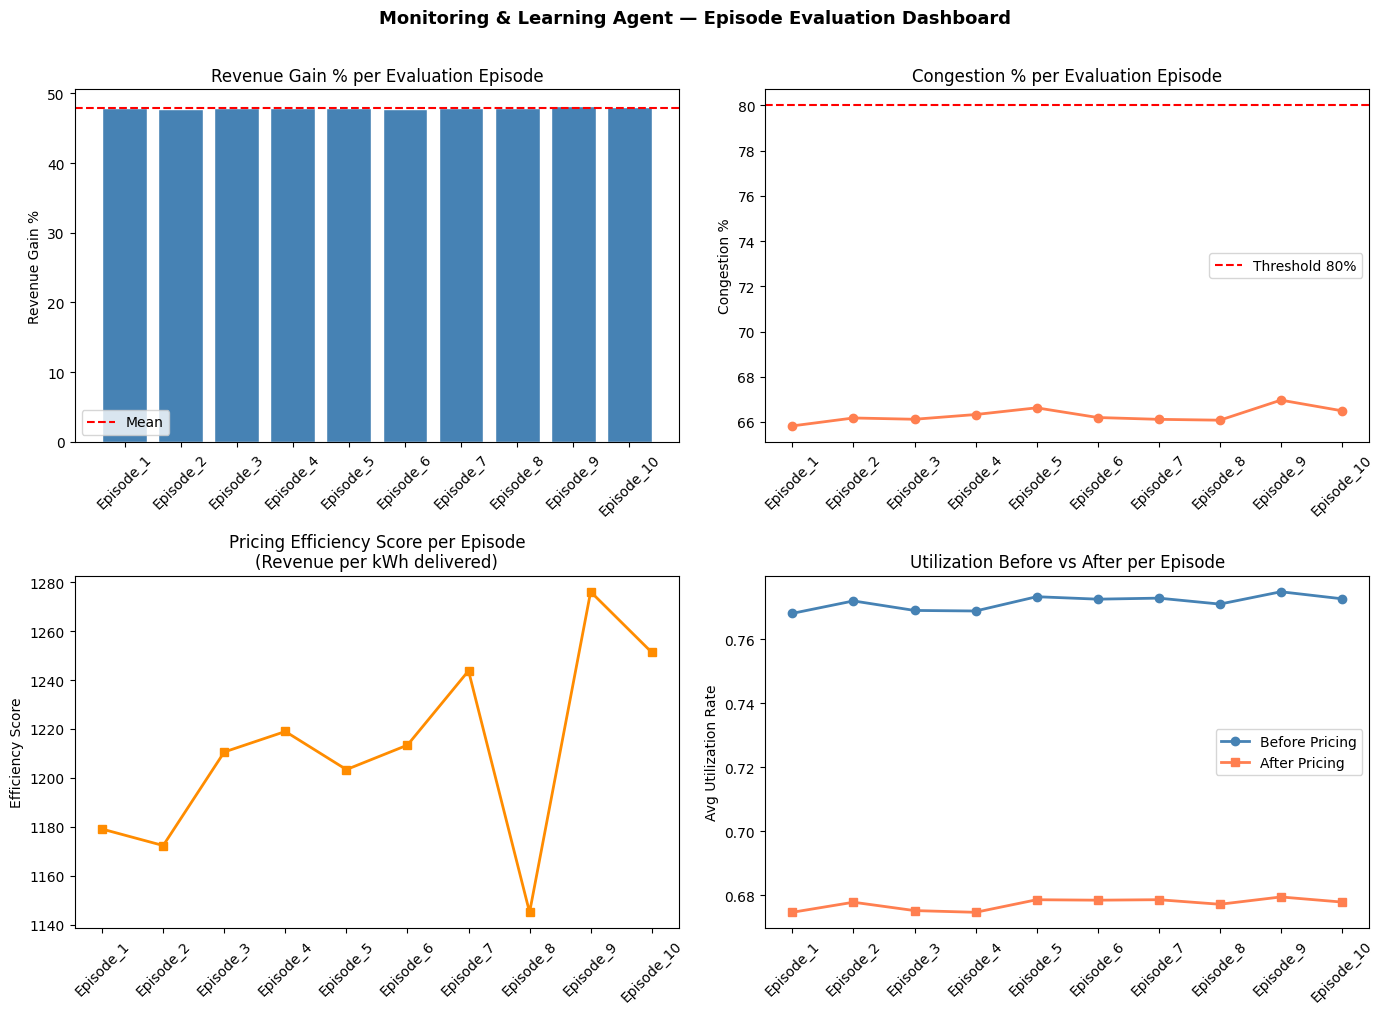

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].bar(episode_stats['episode'], episode_stats['revenue_gain_pct'], 
              color='steelblue', edgecolor='white')
axes[0,0].set_title('Revenue Gain % per Evaluation Episode')
axes[0,0].set_ylabel('Revenue Gain %')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(episode_stats['revenue_gain_pct'].mean(), 
                  color='red', linestyle='--', label='Mean')
axes[0,0].legend()

axes[0,1].plot(episode_stats['episode'], episode_stats['congestion_pct'],
               marker='o', color='coral', linewidth=2)
axes[0,1].set_title('Congestion % per Evaluation Episode')
axes[0,1].set_ylabel('Congestion %')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(80, color='red', linestyle='--', label='Threshold 80%')
axes[0,1].legend()

axes[1,0].plot(episode_stats['episode'], episode_stats['pricing_efficiency'],
               marker='s', color='darkorange', linewidth=2)
axes[1,0].set_title('Pricing Efficiency Score per Episode\n(Revenue per kWh delivered)')
axes[1,0].set_ylabel('Efficiency Score')
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].plot(episode_stats['episode'], episode_stats['avg_predicted_util'],
               marker='o', color='steelblue', linewidth=2, label='Before Pricing')
axes[1,1].plot(episode_stats['episode'], episode_stats['avg_simulated_util'],
               marker='s', color='coral', linewidth=2, label='After Pricing')
axes[1,1].set_title('Utilization Before vs After per Episode')
axes[1,1].set_ylabel('Avg Utilization Rate')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()

plt.suptitle('Episode Evaluation Dashboard', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'monitoring_agent_dashboard.png', bbox_inches='tight')
plt.show()

In [ ]:
monitoring_summary = pd.DataFrame({
    'metric': [
        'Avg Wait Time Before (mins)',
        'Avg Wait Time After (mins)',
        'Wait Time Reduction %',
        'Customer Response Rate %',
        'Surge Zone Decisions %',
        'Discount Zone Decisions %',
        'Avg Revenue Gain % across Episodes',
        'Avg Pricing Efficiency Score',
        'Prediction RMSE ST-EVCDP',
        'Prediction R2 ST-EVCDP'
    ],
    'value': [
        round(avg_wait_before, 3),
        round(avg_wait_after, 3),
        round(wait_reduction_pct, 1),
        round(customer_response, 2),
        round(surge_response/total_decisions*100, 1),
        round(discount_response/total_decisions*100, 1),
        round(episode_stats['revenue_gain_pct'].mean(), 2),
        round(episode_stats['pricing_efficiency'].mean(), 2),
        0.0353,
        0.9892
    ]
})

monitoring_summary.to_csv(OUTPUT_PATH + 'monitoring_agent_summary.csv', index=False)

print("Saved: monitoring_agent_summary.csv")
print("\nFull Monitoring Summary:")
print(monitoring_summary.to_string(index=False))

Saved: monitoring_agent_summary.csv

Full Monitoring Summary:
                            metric     value
       Avg Wait Time Before (mins)    6.3820
        Avg Wait Time After (mins)    1.5580
             Wait Time Reduction %   75.6000
          Customer Response Rate %  100.0000
            Surge Zone Decisions %   66.3000
         Discount Zone Decisions %   16.2000
Avg Revenue Gain % across Episodes   47.9100
      Avg Pricing Efficiency Score 1211.4100
          Prediction RMSE ST-EVCDP    0.0353
            Prediction R2 ST-EVCDP    0.9892

All notebooks complete! Ready for slides.
